# Predicting Student's Mental Health Score from Social Media Usage:

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


.

.

## 2. Load the Dataset

In [3]:
df = pd.read_csv("/content/Student Social Media And Mental Health Impact.csv")

.

.

## 3. Basic Data Understanding

### 3.1 Check 1st 5 rows

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


.

### 3.2 Shapes

In [11]:
# Rows & columns

df.shape

(5000, 13)

### 3.3 Encoding ? (need 6 encoding for 6 objects)

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


### 3.4 Null values ?

In [9]:
# any null value?
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


.

### 3.5 Duplicated values ?

In [14]:

df.duplicated().sum()

np.int64(2)

### 3.6 Describe values:

In [8]:

df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


-> min(Physical_Activity_Hours) = -0.4 hours

lol -ve time value

### 3.7 Unique values count

In [6]:
df.nunique()

,0
Age,7
Gender,2
Country,111
Academic_Level,3
Most_Used_Platform,12
Purpose_Of_Use,4
Avg_Daily_Usage_Hours,79
Daily_Unlocks,200
Study_Hours,76
Physical_Activity_Hours,44


.

.

## 4. Exploratory Data Analysis (EDA):

### 4.1 Histogram of all Numeric columns:

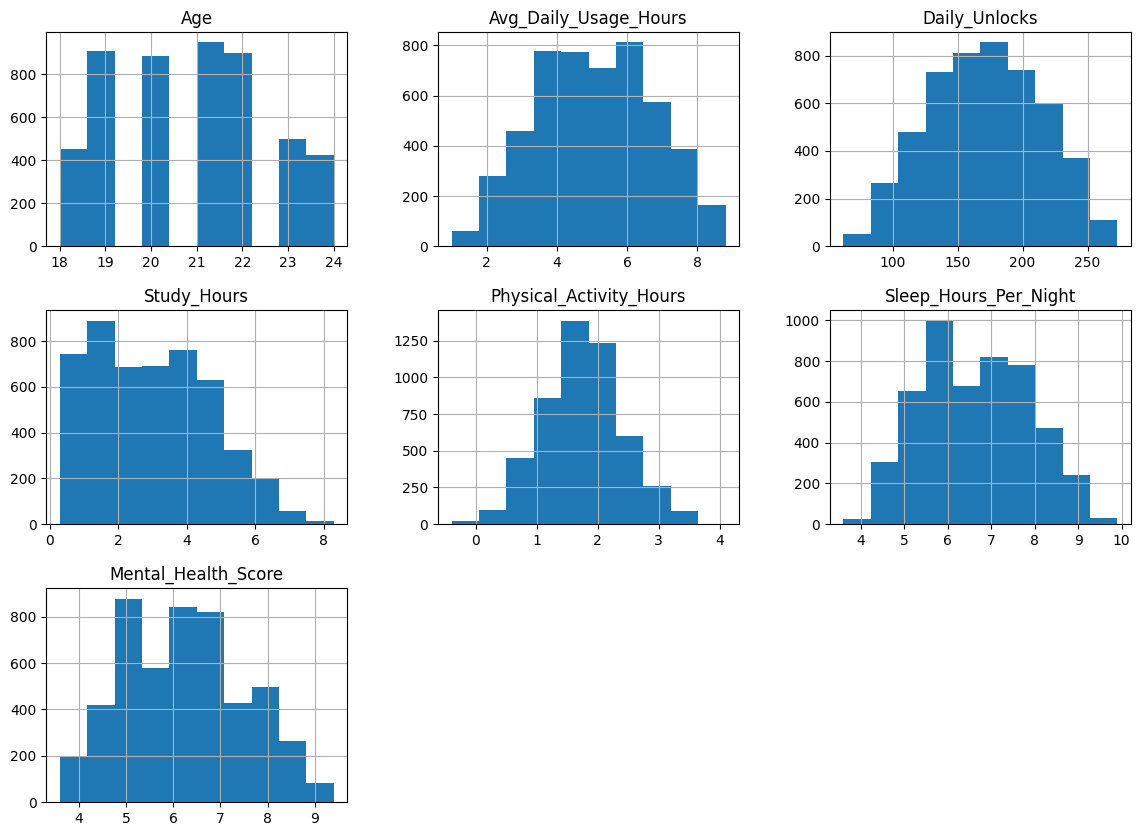

In [18]:
# Histogram of numeric datas:

df.hist(figsize=(14,10))
plt.show()

.

### 4.2 Distribution of the target

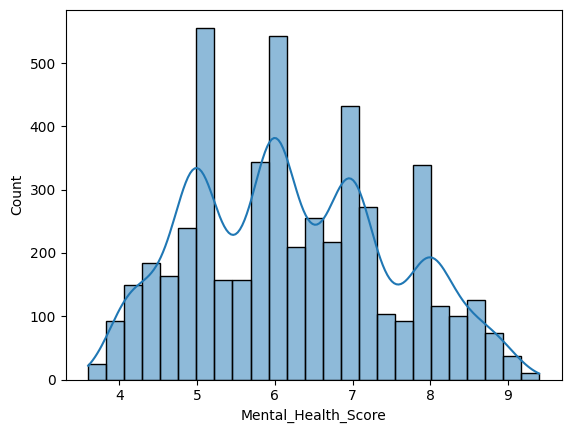

In [20]:

sns.histplot(df["Mental_Health_Score"], kde=True)   # Kernel Density Estimator -> for bell-shaped curve
plt.show()

.

### 4.3 Correlation Heatmap (corr of numeric features):

In [27]:

corr_matrix = df.corr(numeric_only=True)
corr_matrix["Mental_Health_Score"].sort_values(ascending=False)


,Mental_Health_Score
Mental_Health_Score,1.000000
Sleep_Hours_Per_Night,0.766430
Study_Hours,0.752626
Physical_Activity_Hours,0.521374
Age,0.100785
Daily_Unlocks,-0.790851
Avg_Daily_Usage_Hours,-0.816453


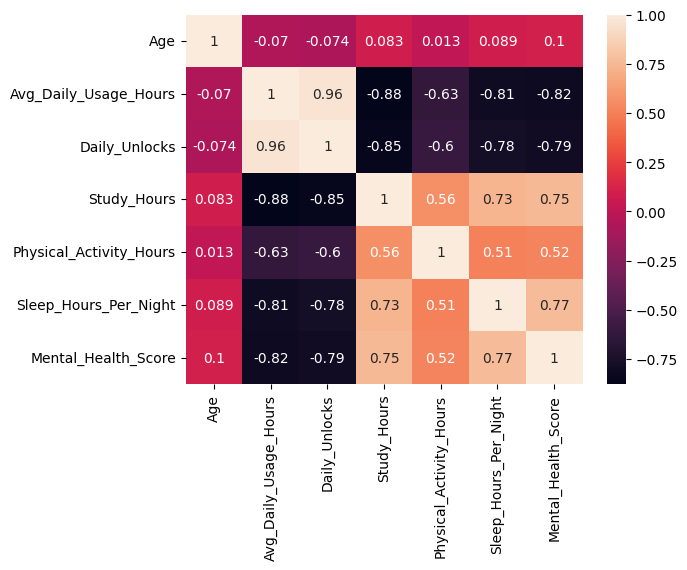

In [25]:

sns.heatmap(corr_matrix, annot=True)  # show numbers
plt.show()


.

### 4.4 Stress_Level vs Mental_Health_Score:

In [28]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [30]:

stress_order = ['Low', 'Medium', 'High', 'Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

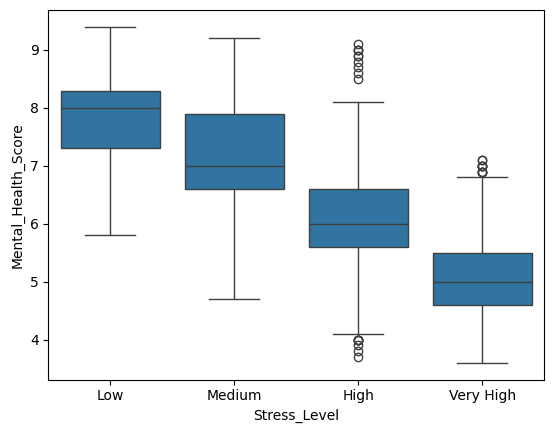

In [35]:

sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=stress_order)


I see outliers at "high" & "Very High"

.

### 4.5 Avg_Daily_Usage_Hours vs Mental_Health_Score

-> had -ve corr

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

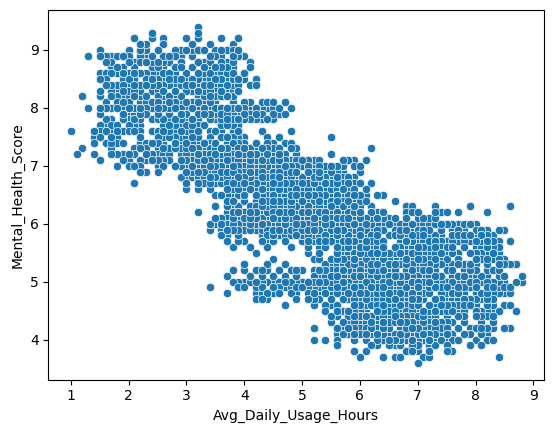

In [43]:

sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)


.

### 4.6 Sleep_Hours_Per_Night vs Mental_Health_Score

had +ve corr

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

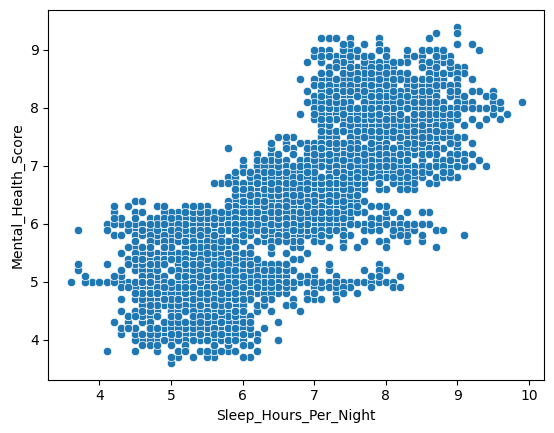

In [113]:

sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)


.

### 4.7 Most Used Platform (counts):

In [47]:
# i see them in descending order.. nice

df["Most_Used_Platform"].value_counts()


,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


.

In [57]:
df["Most_Used_Platform"].value_counts().index

Index(['Instagram', 'TikTok', 'Facebook', 'LinkedIn', 'YouTube', 'Twitter',
       'Snapchat', 'WhatsApp', 'LINE', 'VKontakte', 'KakaoTalk', 'WeChat'],
      dtype='object', name='Most_Used_Platform')

.

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

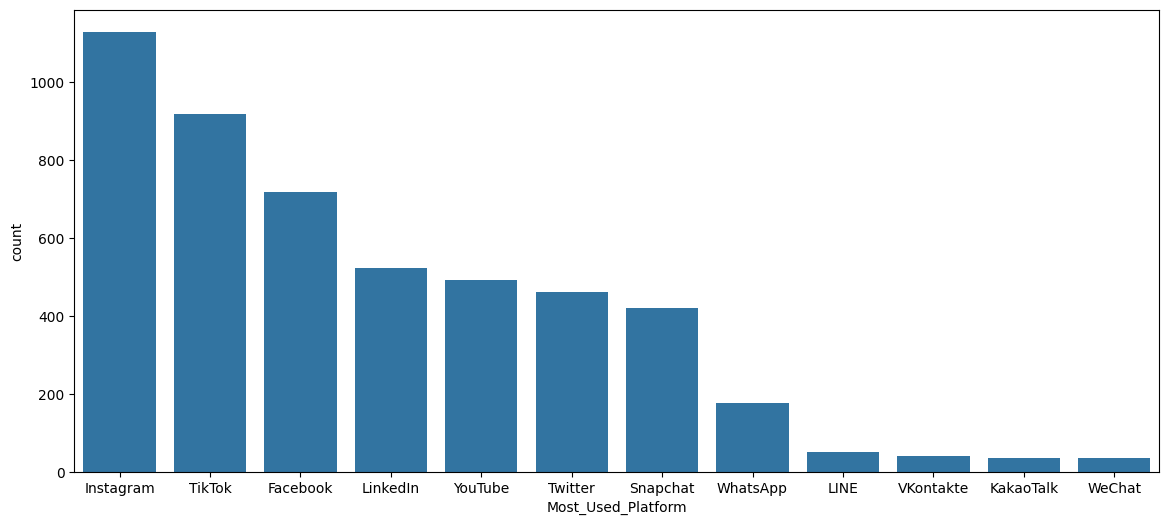

In [59]:

plt.figure(figsize=(14,6))
sns.countplot(x=df['Most_Used_Platform'], order=df["Most_Used_Platform"].value_counts().index )


.

### 4.8 **Checking Outliers:** (On Numerical Features)

Outlier:
- Any values below lower-vound &
- any values above upper-bound.

  - BTW, any values betwn lower-bound & upper-bound are true/correct value.

- Q1 = Value below which 25% of the data lies.
- Q2 = Value below which 50% of the data lies (Median).
- Q3 = Value below which 75% of the data lies.
- IQR (Interquartile Range) = The spread of the middle 50% of the data.

e.g. Sorted Data: 2 4 6 8 10 12 14 16

i.e. 2 4 | 6 8 | 10 12 | 14 16

- Q2 = (8 + 10) / 2 = 9
- Q1 = (4 + 6) / 2 = 5     (on left half from median/Q2)
- Q3 = (12 + 14) / 2 = 13  (median of right half from Q2)
- IQR = Q3 - Q1 =  13 - 5 = 8

In [69]:

num_features = df.select_dtypes(include='number')

# Q1, Q3, IQR of every numeric columns ( Q1, Q3, IQR of Age, Q1, Q3, IQR of Study_Hours, ...):
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

# lower_bound & upper_bound of every numeric columns
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# outliers of every numeric columns
outliers = (num_features < lower_bound) | (num_features > upper_bound)

print(outliers.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [72]:
(24/5000) * 100

0.48

only 0.48% of the data are outlier.. I can *ignore it*.

.

.

.

.

## 5. Data Cleaning:

### 5.1 Drop Duplicates

In [75]:

df = df.drop_duplicates()


In [76]:
df.shape

(4998, 13)

2 duplicated rows removed.

.

### 5.2 Fix an Invalid -ve values or unrealitstic value: (clip used)

Options:
1. Clip the values
2. Drop the rows
3. Replace with NaN and impute with fillna()

In [73]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


  - min(Physical_Activity_Hours) = -0.4  

  fix it

In [77]:

# Converting negative or unrealitstic value to realistic value:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0) # any value lower than 0, replace it with 0.


.

.

.

## 6. Check skewness on Numeric columns; log-transform the column that need it:

- Centralized (near to 0) : mean = median = mode
- Right-skewed (positive-skew value) : mean > median > mode
- Left-skewed / Left-tailed (negative-skew value) : mean < median < mode

In [78]:

num_features = df.select_dtypes(include='number')
num_features.skew()


,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


.

.

.

## 7. Feature Engineering:

In [81]:
df.nunique()

,0
Age,7
Gender,2
Country,111
Academic_Level,3
Most_Used_Platform,12
Purpose_Of_Use,4
Avg_Daily_Usage_Hours,79
Daily_Unlocks,200
Study_Hours,76
Physical_Activity_Hours,40


- `Country` has 111 unique Category or text-values. OneHotEncoding would directly add 110+ mostly-empty columns, ... which hurts the model (efficiency ) far more than it helps. (called `High Cardinality`)

- The fix: `Feature Engineering`... keep the top 10 most frequent countries (that contributes) as their own category, & bucket everything else into `Other`.

.

In [91]:
df["Country"].value_counts()

,count
Country,
Other,1879
India,389
USA,354
Canada,230
Australia,198
...,...
Armenia,1
Bosnia,1
Kuwait,1


In [97]:
top_countries = df["Country"].value_counts().index[:10].tolist()

In [98]:

def group_countries(country):
  if country in top_countries:
    return country

  else:
    return 'Other'


In [99]:

df["Grouped_country"] = df["Country"].apply(group_countries)    # apply in 'Country' column.


In [101]:
df["Grouped_country"].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


111 Unique category of Country reduced to 10 category only

.

.

.

## 8. Encoding Strategy:

**How to encode each categorical-columns:**

---
---

1. `Stress_Level` : → ***`Ordinal Encoding`***

Its categories have a real, natural,  meaningful order (ranking):

Low < Medium < High < Very High.

- Low       → 0
- Medium    → 1
- High      → 2
- Very High → 3

A larger number means higher stress.

---
---

2. `Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`,  `Country_Grouped` → ***`One-Hot Encoding`***

These categories have no natural order — "Instagram" isn't "greater than" "LinkedIn".

---
---

In [102]:
# I'll implement both of these inside a single ColumnTransformer later.

.

.

.

## 9. Train-Test Split

In [126]:

## Numeric features:

# FunctionTransformer(np.log1p)
skew_col = ["Study_Hours"]

# StandardScaler()
other_numeric_col = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks", "Physical_Activity_Hours",
                     "Sleep_Hours_Per_Night"]



## Categorical features:

# OrdinalEncoder()
ordinal_col        = ['Stress_Level']

# OneHotEncoding()
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]



feature_col = skew_col + other_numeric_col + ordinal_col + normal_col

X = df[feature_col]     # 'Country' not included, ofc.
y = df["Mental_Health_Score"]


In [127]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)



In [128]:

X_train.shape, X_test.shape


((3498, 12), (1500, 12))

.

.

.

## 10. Preprocessing using ColumnTransformer

1. skew_col → FunctionTransformer(np.log1p)
2. other_numeric_col → StandardScaler
3. ordinal_col → OrdinalEncoder()
4. normal_col → OneHotEncoding()

In [129]:


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer


# 1. Skewed features:
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),   # np.log1p wrapped inside a function.
    ('scale', StandardScaler())
])


# 2. Numeric Features:
numeric_pipeline = Pipeline([
    ('scale', StandardScaler())
])


# LabelEncoder might have ranked randomly.
# 3. Ordinal features:
ordinal_pipeline = Pipeline([
    ('encode' , OrdinalEncoder( categories=[['Low', 'Medium', 'High', 'Very High']] )   )    ###### [0, 1, 2, 3] based on index.
])


# 4. Nominal Features
normal_pipeline = Pipeline([
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])




###
preprocessor = ColumnTransformer(transformers=[
    ('SkewProcessed', skew_pipeline, skew_col),
    ('numeric', numeric_pipeline, other_numeric_col),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', normal_pipeline, normal_col),
])



.

.

.

.

## 11. Model Building:

### 11.1 Baseline: Linear Regression

In [156]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)                  # -->> preprocessor -->> LinearRegression()
lr_y_test_preds = lr_pipeline.predict(X_test)      # -->> preprocessor -->> LinearRegression()

# we gotta know whether overfitting, underfitting happened.
lr_y_train_preds = lr_pipeline.predict(X_train)    # -->> preprocessor -->> LinearRegression()


In [157]:

# Evaluate:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, lr_y_test_preds)
lr_mse = mean_squared_error(y_test, lr_y_test_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_y_test_preds))


lr_r2_testing = r2_score(y_test, lr_y_test_preds)
lr_r2_training = r2_score(y_train, lr_y_train_preds)



print(f"lr_MAE: {lr_mae}")
print(f"lr_MSE: {lr_mse}")
print(f"lr_RMSE: {lr_rmse}")
print()
print(f"Testing Accuracy: {lr_r2_testing}")
print(f"Training Accuracy: {lr_r2_training}")


lr_MAE: 0.5361775634720181
lr_MSE: 0.45701905273487986
lr_RMSE: 0.6760318429888342

Testing Accuracy: 0.7397944617433021
Training Accuracy: 0.7236771199387538


1% accuracy difference = very less chance of overfitting.

.

.


1. `Train Accuracy ≫ Test Accuracy`
   - → `Large gap`
   - → This means `Overfitting`.
   - → The model memorized the training data and performs poorly on unseen data.

2. `Train Accuracy ≈ Test Accuracy`
   - → `Small gap`
   - → `Good Generalization`.
   - → The model performs similarly on both training and testing data.

3. `Train Accuracy ≈ Test Accuracy`, `but BOTH are low`
   - → This means `Underfitting`.
   - → The model did not learn enough from the training data, so it performs poorly on both training and testing data.

.

.

### 11.2 Random Forest (Default settings: Before Tuning)

In [158]:

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42) ),
])


rf_pipeline.fit(X_train, y_train)
rf_y_test_preds = rf_pipeline.predict(X_test)

# we gotta know whether overfitting, underfitting happened.
rf_y_train_preds = rf_pipeline.predict(X_train)



In [159]:

# Evaluate:

rf_mae = mean_absolute_error(y_test, rf_y_test_preds)
rf_mse = mean_squared_error(y_test, rf_y_test_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_test_preds))


rf_r2_testing = r2_score(y_test, rf_y_test_preds)
rf_r2_training = r2_score(y_train, rf_y_train_preds)



print(f"rf_MAE: {rf_mae}")
print(f"rf_MSE: {rf_mse}")
print(f"rf_RMSE: {rf_rmse}")
print()
print(f"Testing Accuracy: {rf_r2_testing}")
print(f"Training Accuracy: {rf_r2_training}")



rf_MAE: 0.34722113333333343
rf_MSE: 0.21500011819333337
rf_RMSE: 0.46368105222591677

Testing Accuracy: 0.8775888638668996
Training Accuracy: 0.9808287942404612


- This suggests the model is overfitting.
- But also got low error than with LinearRegression model.

.

.

.

### 11.3 Hyperparameter Tuning:

In [141]:
# The Training accuracy (98.08%) is much higher than the testing accuracy (87.76%),
# indicating that the Random Forest model is likely overfitting.
# Therefore, we perform hyperparameter tuning to improve generalization
# and reduce the gap between training and testing performance.

In [147]:

param_grid = {
    'random_forest__n_estimators': [100, 200, 300, 400],    # n_estimators should goto random_forest tuple... in that rf_pipeline.
    'random_forest__max_depth': [5, 10, 15, 20],
    'random_forest__min_samples_split': [2, 5, 10, 15],
    'random_forest__min_samples_leaf': [1, 2, 4, 6, 8]
}


In [148]:

from sklearn.model_selection import RandomizedSearchCV

# create an object:
random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter = 15,    # iterations
    scoring = 'r2',
    n_jobs = -1,    # use all free processors.
    cv = 5,
    random_state = 42
)

random_search.fit(X_train, y_train)



RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('SkewProcessed',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physical_A...
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15,
                                                                     20],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4,
                                                                            6,
                                                                            8],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10,
                                                                             15],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300,
                                                                        400]},
                   random_state=42, scoring='r2')

.

In [149]:

# Best hyperparameters
random_search.best_params_


{'random_forest__n_estimators': 100,
 'random_forest__min_samples_split': 2,
 'random_forest__min_samples_leaf': 1,
 'random_forest__max_depth': 20}

In [150]:

# Best cross-validation score
print("\nBest CV Score:")
print(random_search.best_score_)



Best CV Score:
0.8516019717114094


In [151]:

# Best model
rf_best_pipeline = random_search.best_estimator_
rf_best_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('SkewProcessed',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('numeric',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Ni...
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('random_forest',
                 RandomForestRegressor(max_depth=20, random_state=42))])

.

In [168]:

# Predictions:
rf_best_y_test_pred = rf_best_pipeline.predict(X_test)
rf_best_y_train_pred = rf_best_pipeline.predict(X_train)



# Evaluation
rf_best_mae = mean_absolute_error(y_test, rf_best_y_test_pred)
rf_best_mse = mean_squared_error(y_test, rf_best_y_test_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_y_test_pred))

rf_best_r2_testing = r2_score(y_test, rf_best_y_test_pred)
rf_best_r2_training = r2_score(y_train, rf_best_y_train_pred)




print("After Hyperparameter Tuning:\n")

print(f"Best_rf_MAE Score: {rf_best_mae}")
print(f"Best_rf_MSE Score: {rf_best_mse}")
print(f"Best_rf_RMSE Score: {rf_best_rmse}\n")

print(f"Best_rf_Testing_R2 Score: {rf_best_r2_testing}")
print(f"Best_rf_Training_R2_ Score: {rf_best_r2_training}")


After Hyperparameter Tuning:

Best_rf_MAE Score: 0.348628666443674
Best_rf_MSE Score: 0.2161938376499269
Best_rf_RMSE Score: 0.4649664908893187

Best_rf_Testing_R2 Score: 0.8769092151479422
Best_rf_Training_R2_ Score: 0.9794403250509641


ahhhh, Even after Hyperparameter Tuning, I got kind of same MAE & R_2 Score. So, I can use any of these two;

1. rf_pipeline (Default)
2. rf_best_pipeline (Tuned)

.

.

.

.

## 12. All Models Evaluation:

In [176]:

# Create a DataFrame:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'MAE': [lr_mae, rf_mae, rf_best_mae],
    'MSE': [lr_mse, rf_mse, rf_best_mse],
    'RMSE': [lr_rmse, rf_rmse, rf_best_rmse],
    'R2_Testing': [lr_r2_testing, rf_r2_testing, rf_best_r2_testing],
    'R2_Training': [lr_r2_training, rf_r2_training, rf_best_r2_training]
})

results


,Model,MAE,MSE,RMSE,R2_Testing,R2_Training
0,Linear Regression,0.536178,0.457019,0.676032,0.739794,0.723677
1,Random Forest (default),0.347221,0.215000,0.463681,0.877589,0.980829
2,Random Forest (tuned),0.348629,0.216194,0.464966,0.876909,0.979440


.

.

.

.

## 13. Save the Model:

In [178]:

import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')
print("Model Saved!!")


Model Saved!!
